# Can menstrual health and user-profile data reveal patterns associated with PCOS symptoms, PMS, and well-being?


In [ ]:
pip install git+https://github.com/stavskal/ADASYN

  Cloning https://github.com/stavskal/ADASYN to /tmp/pip-req-build-z2nyz1v1
  Running command git clone --filter=blob:none --quiet https://github.com/stavskal/ADASYN /tmp/pip-req-build-z2nyz1v1
  Resolved https://github.com/stavskal/ADASYN to commit f6a7ee26a51f18baacaf7b291811c9e9a9097a9f
  Preparing metadata (setup.py) ... done


# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Load both dataset files from the drive and print the heads for both
period_log = '/content/drive/MyDrive/Project/Period_Log.csv'
user_profile = '/content/drive/MyDrive/Project/User_Profile.csv'

period = pd.read_csv(period_log)
users = pd.read_csv(user_profile)

print("Period Log:")
display(period.head())

print("User Profiles:")
display(users.head())

Period Log:


,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,...,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period
0,U00001,1,2024-02-13,33,NaN,Luteal,Heavy,9,Yes,6,...,5.3,6,7,5.1,84.7,4.14,Positive,6.5,0.949,0
1,U00001,2,2024-03-17,33,33.0,Follicular,Light,2,No,8,...,4.6,7,8,2.6,126.1,2.79,Negative,9.4,0.949,1
2,U00001,3,2024-04-19,34,33.0,Follicular,Heavy,8,No,5,...,5.1,5,5,6.8,131.1,1.70,Negative,6.7,0.949,1
3,U00001,4,2024-05-23,31,34.0,Luteal,Light,3,No,8,...,6.7,8,8,2.5,82.0,8.50,Negative,9.0,0.949,0
4,U00001,5,2024-06-23,31,31.0,Luteal,Moderate,3,No,9,...,5.8,9,8,2.4,55.5,6.30,Negative,9.3,0.949,1


User Profiles:


,user_id,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,U00001,Rhode Island,34,26.0,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
1,U00002,New Hampshire,32,26.6,Good,5–6 days/week,5.5,2.9,2.3,Weekly,No,0,0,5.7
2,U00003,Iowa,18,16.0,Poor,1–2 days/week,6.7,0.5,2.1,Never,No,1,0,3.1
3,U00004,Texas,30,24.7,Excellent,NaN,7.3,0.4,1.8,Occasionally,No,1,0,6.6
4,U00005,Delaware,32,29.2,Good,1–2 days/week,7.1,2.2,2.2,Occasionally,No,0,1,3.1


# Merge datasets and select relevant columns

In [ ]:
print("Column titles for Period Log:")
print(period.columns.tolist())

Column titles for Period Log:
['user_id', 'cycle_number', 'start_date', 'cycle_length_days', 'prev_cycle_length', 'cycle_phase', 'flow_level', 'pain_level', 'pms_symptoms', 'mood_score', 'stress_score_cycle', 'sleep_hours_cycle', 'energy_level', 'concentration_score', 'work_hours_lost', 'estrogen_pgml', 'progesterone_ngml', 'ovulation_result', 'overall_health_score', 'log_consistency_score', 'prepared_before_period']


In [ ]:
merged_data = pd.merge(period, users, on='user_id', how='inner')

print("Merged Data:")
display(merged_data.head())

Merged Data:


,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,...,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,U00001,1,2024-02-13,33,NaN,Luteal,Heavy,9,Yes,6,...,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
1,U00001,2,2024-03-17,33,33.0,Follicular,Light,2,No,8,...,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
2,U00001,3,2024-04-19,34,33.0,Follicular,Heavy,8,No,5,...,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
3,U00001,4,2024-05-23,31,34.0,Luteal,Light,3,No,8,...,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
4,U00001,5,2024-06-23,31,31.0,Luteal,Moderate,3,No,9,...,Good,5–6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1


In [ ]:
selected_columns = ['user_id', 'age', 'bmi', 'cycle_phase', 'pms_symptoms', 'pcos_diagnosed', 'stress_score_baseline', 'energy_level', 'concentration_score', 'mood_score', 'sleep_hours']
merged_data_selected = merged_data[selected_columns]


df = merged_data_selected[selected_columns].copy()

print("Analysis dataframe:")
display(df.head())

Analysis dataframe:


,user_id,age,bmi,cycle_phase,pms_symptoms,pcos_diagnosed,stress_score_baseline,energy_level,concentration_score,mood_score,sleep_hours
0,U00001,34,26.0,Luteal,Yes,1,4.1,6,7,6,5.4
1,U00001,34,26.0,Follicular,No,1,4.1,7,8,8,5.4
2,U00001,34,26.0,Follicular,No,1,4.1,5,5,5,5.4
3,U00001,34,26.0,Luteal,No,1,4.1,8,8,8,5.4
4,U00001,34,26.0,Luteal,No,1,4.1,9,8,9,5.4


# Data check

In [ ]:
print("Missing values in selected columns:")
display(df.isnull().sum())

Missing values in selected columns:


,0
user_id,0
age,0
bmi,0
cycle_phase,0
pms_symptoms,0
pcos_diagnosed,0
stress_score_baseline,0
energy_level,0
concentration_score,0
mood_score,0


In [ ]:
# Check data types
print("Data types:")
display(df.dtypes)

# Check unique values for key categorical columns
print("Unique values in cycle_phase:")
display(df['cycle_phase'].unique())

print("Unique values in pcos_diagnosed:")
display(df['pcos_diagnosed'].unique())

Data types:


,0
user_id,object
age,int64
bmi,float64
cycle_phase,object
pms_symptoms,object
pcos_diagnosed,int64
stress_score_baseline,float64
energy_level,int64
concentration_score,int64
mood_score,int64


Unique values in cycle_phase:


array(['Luteal', 'Follicular', 'Menstrual'], dtype=object)

Unique values in pcos_diagnosed:


array([1, 0])

In [ ]:
#Print a random user's information to check how the variables look for different users
random_user_id = df['user_id'].sample(1).iloc[0]
random_user_data = df[df['user_id'] == random_user_id]

print(f"Data for random user: {random_user_id}")
display(random_user_data)

Data for random user: U00403


,user_id,age,bmi,cycle_phase,pms_symptoms,pcos_diagnosed,stress_score_baseline,energy_level,concentration_score,mood_score,sleep_hours
3643,U00403,21,25.4,Follicular,No,0,6.3,5,6,5,6.9
3644,U00403,21,25.4,Luteal,No,0,6.3,4,7,6,6.9
3645,U00403,21,25.4,Luteal,No,0,6.3,4,8,6,6.9
3646,U00403,21,25.4,Luteal,No,0,6.3,4,6,7,6.9
3647,U00403,21,25.4,Follicular,Yes,0,6.3,8,8,7,6.9
3648,U00403,21,25.4,Follicular,Yes,0,6.3,6,6,7,6.9
3649,U00403,21,25.4,Luteal,No,0,6.3,8,8,9,6.9
3650,U00403,21,25.4,Follicular,No,0,6.3,7,10,6,6.9
3651,U00403,21,25.4,Luteal,No,0,6.3,7,6,9,6.9
3652,U00403,21,25.4,Follicular,No,0,6.3,7,9,10,6.9


# User Level dataset with cycle phase being luteal as PMS usually shows during the luteal phase

In [ ]:
# Create a user-level dataset during luteal phase
# Filter the DataFrame to include only the 'Luteal' phase
df_luteal = df[df['cycle_phase'] == 'Luteal'].copy()

user_level_df = df_luteal.groupby('user_id').agg({
    'cycle_phase': 'first', # After filtering, 'first' will correctly pick 'Luteal'
    'age': 'first',
    'bmi': 'first',
    'pms_symptoms': 'max',          # If PMS appears at least once → mark user as PMS
    'pcos_diagnosed': 'first',      # Diagnosis should be constant per user
    'stress_score_baseline': 'mean',
    'energy_level': 'mean',
    'concentration_score': 'mean',
    'sleep_hours': 'mean',
}).reset_index()

print("User-level dataset (one row per user):")
display(user_level_df.head())

print("Number of unique users:")
print(user_level_df['user_id'].nunique())

User-level dataset (one row per user):


,user_id,cycle_phase,age,bmi,pms_symptoms,pcos_diagnosed,stress_score_baseline,energy_level,concentration_score,sleep_hours
0,U00001,Luteal,34,26.0,Yes,1,4.1,7.571429,8.000000,5.4
1,U00002,Luteal,32,26.6,Yes,0,5.7,7.000000,6.800000,5.5
2,U00003,Luteal,18,16.0,No,0,3.1,7.333333,8.333333,6.7
3,U00004,Luteal,30,24.7,Yes,0,6.6,5.750000,7.500000,7.3
4,U00006,Luteal,28,21.4,Yes,0,4.8,7.250000,6.750000,7.6


Number of unique users:
1972


### User-Level Dataset for Follicular Phase

In [ ]:
# Create a user-level dataset during follicular phase
# Filter the DataFrame to include only the 'Follicular' phase
df_follicular = df[df['cycle_phase'] == 'Follicular'].copy()

user_level_df_follicular = df_follicular.groupby('user_id').agg({
    'cycle_phase': 'first', # After filtering, 'first' will correctly pick 'Follicular'
    'age': 'first',
    'bmi': 'first',
    'pms_symptoms': 'max',          # If PMS appears at least once → mark user as PMS
    'pcos_diagnosed': 'first',      # Diagnosis should be constant per user
    'stress_score_baseline': 'mean',
    'energy_level': 'mean',
    'concentration_score': 'mean',
    'sleep_hours': 'mean',
}).reset_index()

print("User-level dataset for Follicular phase (one row per user):")
display(user_level_df_follicular.head())

print("Number of unique users in Follicular phase dataset:")
print(user_level_df_follicular['user_id'].nunique())

User-level dataset for Follicular phase (one row per user):


,user_id,cycle_phase,age,bmi,pms_symptoms,pcos_diagnosed,stress_score_baseline,energy_level,concentration_score,sleep_hours
0,U00001,Follicular,34,26.0,No,1,4.1,6.5,7.000000,5.4
1,U00002,Follicular,32,26.6,No,0,5.7,7.0,8.333333,5.5
2,U00003,Follicular,18,16.0,No,0,3.1,10.0,9.333333,6.7
3,U00004,Follicular,30,24.7,Yes,0,6.6,6.5,7.250000,7.3
4,U00005,Follicular,32,29.2,No,1,3.1,8.8,8.000000,7.1


Number of unique users in Follicular phase dataset:
1981


## Convert PMS symptoms to binary

In [ ]:
# Ensure PMS is binary in both df
user_level_df['pms_symptoms'] = user_level_df['pms_symptoms'].map({
    'Yes': 1,
    'No': 0
})

display(user_level_df.head())


,user_id,cycle_phase,age,bmi,pms_symptoms,pcos_diagnosed,stress_score_baseline,energy_level,concentration_score,sleep_hours
0,U00001,Luteal,34,26.0,1,1,4.1,7.571429,8.000000,5.4
1,U00002,Luteal,32,26.6,1,0,5.7,7.000000,6.800000,5.5
2,U00003,Luteal,18,16.0,0,0,3.1,7.333333,8.333333,6.7
3,U00004,Luteal,30,24.7,1,0,6.6,5.750000,7.500000,7.3
4,U00006,Luteal,28,21.4,1,0,4.8,7.250000,6.750000,7.6


In [ ]:
# Ensure PMS is binary in both df

user_level_df_follicular['pms_symptoms'] = user_level_df_follicular['pms_symptoms'].map({
    'Yes': 1,
    'No': 0
})

display(user_level_df_follicular.head())

,user_id,cycle_phase,age,bmi,pms_symptoms,pcos_diagnosed,stress_score_baseline,energy_level,concentration_score,sleep_hours
0,U00001,Follicular,34,26.0,0,1,4.1,6.5,7.000000,5.4
1,U00002,Follicular,32,26.6,0,0,5.7,7.0,8.333333,5.5
2,U00003,Follicular,18,16.0,0,0,3.1,10.0,9.333333,6.7
3,U00004,Follicular,30,24.7,1,0,6.6,6.5,7.250000,7.3
4,U00005,Follicular,32,29.2,0,1,3.1,8.8,8.000000,7.1


## Comparison of Key Metrics between Luteal and Follicular Phases

Average of key metrics by cycle phase:


,Luteal Phase Mean,Follicular Phase Mean
pms_symptoms,0.723631,0.701161
stress_score_baseline,5.590314,5.585411
energy_level,6.718179,6.929980
concentration_score,7.243089,7.437448
sleep_hours,6.994473,6.994700


/tmp/ipykernel_25331/1240866705.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Phase', y='Mean Value', data=data_to_plot, ax=axes[i], palette={'Luteal': 'skyblue', 'Follicular': 'lightcoral'})
/tmp/ipykernel_25331/1240866705.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Phase', y='Mean Value', data=data_to_plot, ax=axes[i], palette={'Luteal': 'skyblue', 'Follicular': 'lightcoral'})
/tmp/ipykernel_25331/1240866705.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Phase', y='Mean Value', data=data_to_plot, ax=axes[i], 

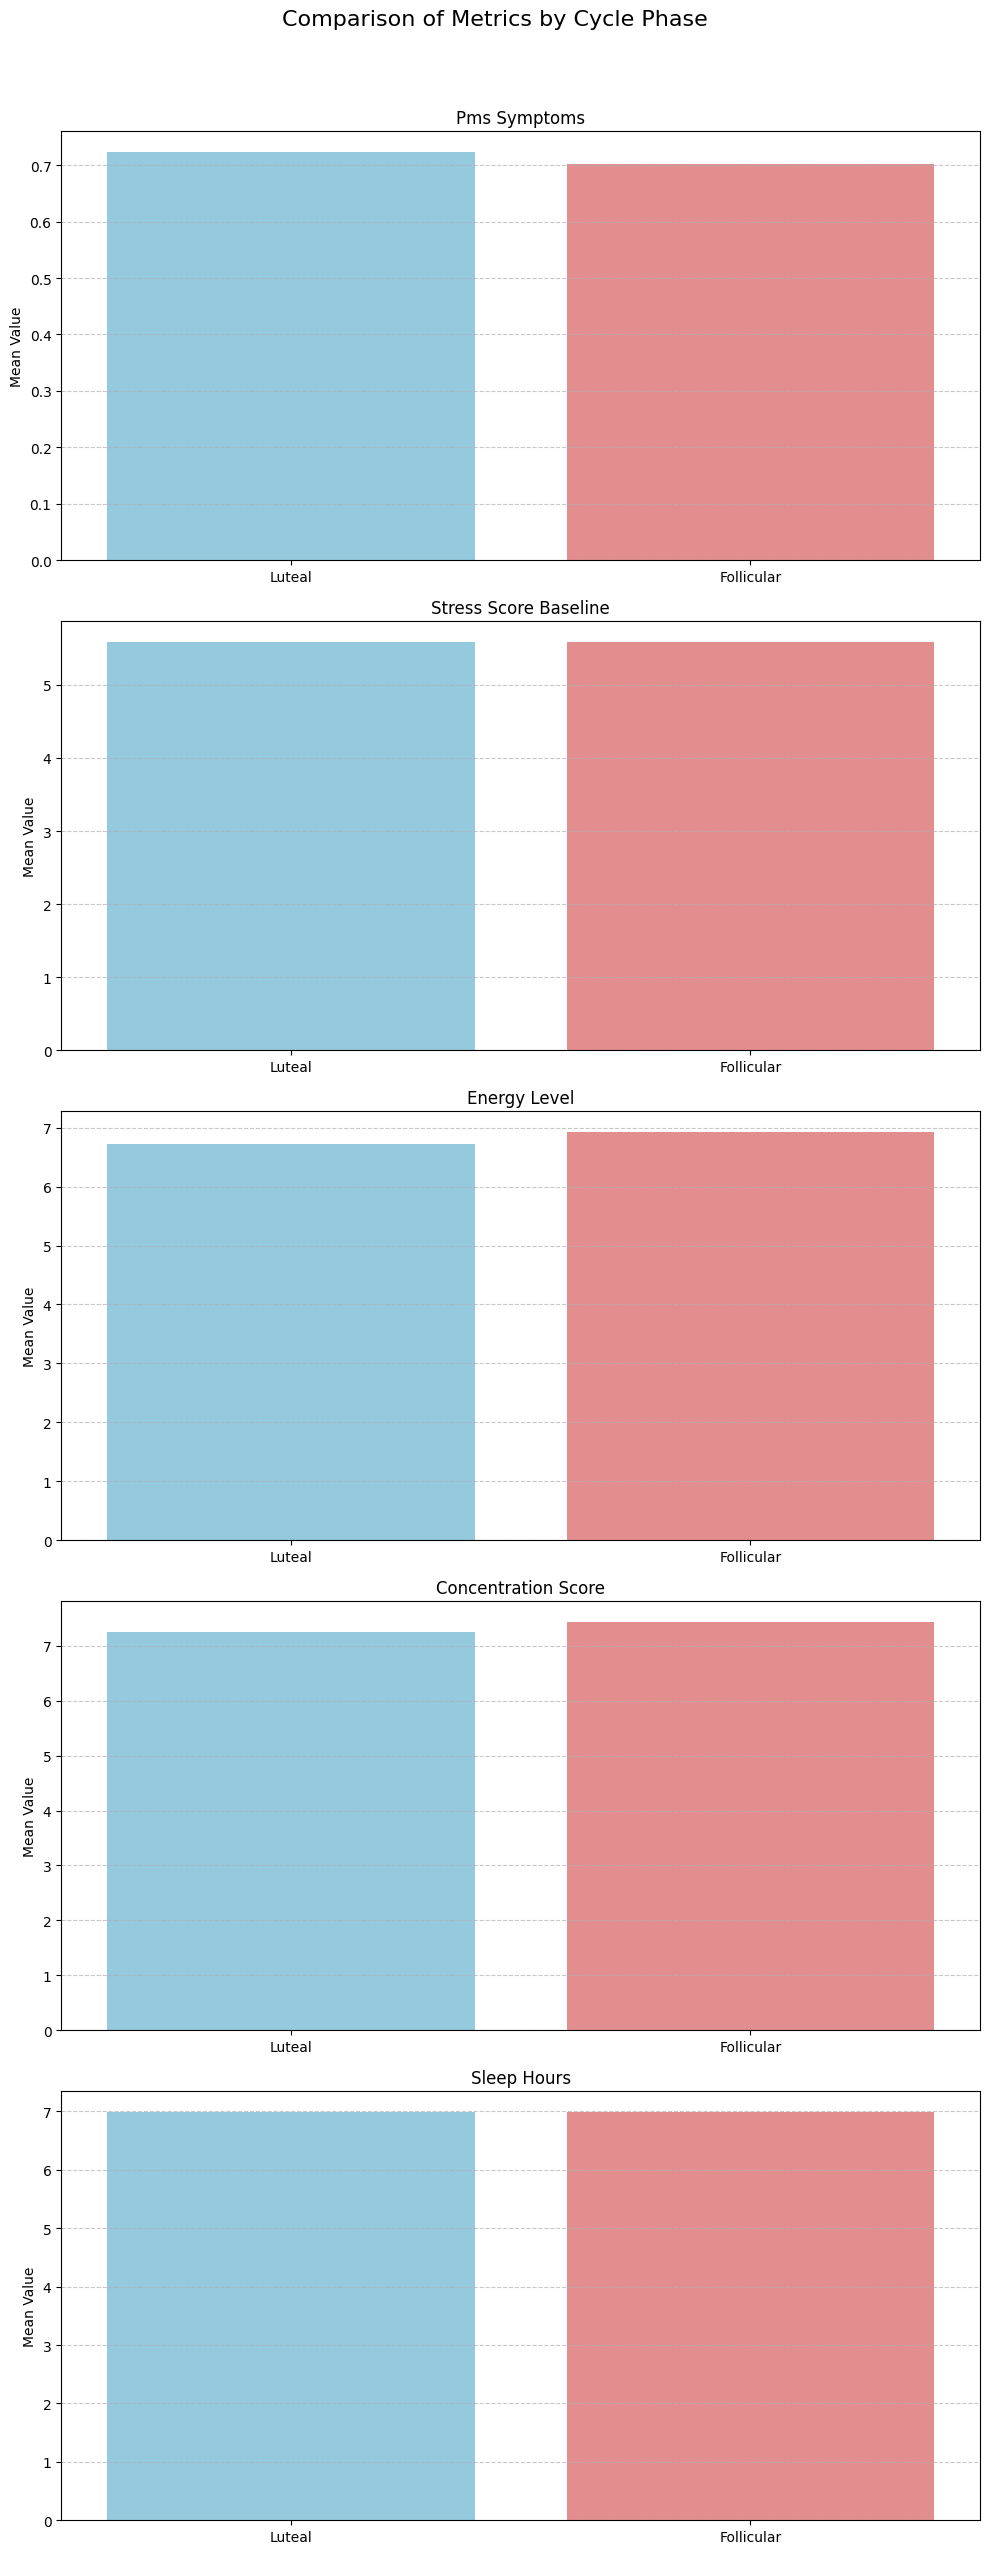

In [ ]:
# Select key metrics for comparison
metrics_to_compare = ['pms_symptoms', 'stress_score_baseline', 'energy_level', 'concentration_score', 'sleep_hours']

# Calculate mean for Luteal phase
luteal_means = user_level_df[metrics_to_compare].mean().rename('Luteal Phase Mean')

# Calculate mean for Follicular phase
follicular_means = user_level_df_follicular[metrics_to_compare].mean().rename('Follicular Phase Mean')

# Combine into a single DataFrame for easy comparison
comparison_df = pd.concat([luteal_means, follicular_means], axis=1)

print("Average of key metrics by cycle phase:")
display(comparison_df)

# Optional: Visualize the comparison
fig, axes = plt.subplots(len(metrics_to_compare), 1, figsize=(10, 5 * len(metrics_to_compare)))
fig.suptitle('Comparison of Metrics by Cycle Phase', y=1.02, fontsize=16)

for i, metric in enumerate(metrics_to_compare):
    data_to_plot = pd.DataFrame({
        'Metric': [metric, metric],
        'Phase': ['Luteal', 'Follicular'],
        'Mean Value': [luteal_means[metric], follicular_means[metric]]
    })
    sns.barplot(x='Phase', y='Mean Value', data=data_to_plot, ax=axes[i], palette={'Luteal': 'skyblue', 'Follicular': 'lightcoral'})
    axes[i].set_title(f'{metric.replace("_", " ").title()}')
    axes[i].set_ylabel('Mean Value')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Check there's one row per user and check for missing values

In [ ]:
print("Rows:", len(user_level_df))
print("Unique users:", user_level_df['user_id'].nunique())

Rows: 1972
Unique users: 1972


### checking how many users have pms symptoms and how many don't


In [ ]:
print("PMS Symptoms Distribution (User-Level):")
display(user_level_df['pms_symptoms'].value_counts())

PMS Symptoms Distribution (User-Level):


,count
pms_symptoms,
1,1427
0,545


In [ ]:
print("Missing values:")
display(user_level_df.isnull().sum())

Missing values:


,0
user_id,0
cycle_phase,0
age,0
bmi,0
pms_symptoms,0
pcos_diagnosed,0
stress_score_baseline,0
energy_level,0
concentration_score,0
sleep_hours,0


## Define “Severe PMS” -- not used in updated models
change the way it was calculated, to now calclating weighted score and then setting a threshold

In [ ]:
user_level_df['pms_severity_score'] = (
    0.5 * user_level_df['stress_score_baseline'] +
    0.3 * (10 - user_level_df['energy_level']) +
    0.2 * (10 - user_level_df['concentration_score'])
)

display(user_level_df[['pms_severity_score']].head())

,pms_severity_score
0,3.368182
1,4.283333
2,2.368182
3,5.000000
4,2.183333


In [ ]:
threshold = user_level_df['pms_severity_score'].quantile(0.75)

print("Threshold for Severe PMS:", threshold)

Threshold for Severe PMS: 5.1


In [ ]:
print(user_level_df['pms_severity_score'].value_counts())

pms_severity_score
4.700000    9
5.150000    8
4.250000    8
4.800000    7
4.950000    7
           ..
3.627778    1
4.358333    1
5.322222    1
5.958333    1
4.233333    1
Name: count, Length: 1475, dtype: int64


In [ ]:
max_pms = user_level_df['pms_severity_score'].max()
print("Maximum PMS severity score:", max_pms)

min_pms = user_level_df['pms_severity_score'].min()
print("Minimum PMS severity score:", min_pms)

average_pms = user_level_df['pms_severity_score'].mean()
print("Average PMS severity score:", average_pms)

median_pms = user_level_df['pms_severity_score'].median()
print("Median PMS severity score:", median_pms)

Maximum PMS severity score: 7.464285714285715
Minimum PMS severity score: 0.9083333333333331
Average PMS severity score: 4.272942503607504
Median PMS severity score: 4.3125


In [ ]:
print("Missing values:")
display(user_level_df.isnull().sum())

Missing values:


,0
user_id,0
pms_symptoms,0
pcos_diagnosed,0
stress_score_baseline,0
energy_level,0
concentration_score,0
pms_binary,0
mood_score,0
pms_severity_score,0


### Categorize Severe PMS

In [ ]:
user_level_df['severe_pms'] = np.where(
    user_level_df['pms_severity_score'] >= threshold,
    1,
    0
)

print("PMS Severity Score Median:", user_level_df['pms_severity_score'].median())
display(user_level_df[['pms_severity_score','severe_pms']].head())

PMS Severity Score Median: 4.3125


,pms_severity_score,severe_pms
0,3.368182,0
1,4.283333,0
2,2.368182,0
3,5.000000,0
4,2.183333,0


### Compare probability of severe PMS in PCOS vs non-PCOS

In [ ]:
severe_pms_rate = user_level_df.groupby('pcos_diagnosed')['severe_pms'].mean()*100

print("Probability of severe PMS (%):")
display(severe_pms_rate)

Probability of severe PMS (%):


,severe_pms
pcos_diagnosed,
0,24.673203
1,29.878049


### find how many have pcos and severe pms (and the opposite)

In [ ]:
non_pcos_severe_pms = user_level_df[(user_level_df['pcos_diagnosed'] == 0) & (user_level_df['pms_severity_score'] >= 5.1)]

print(f"Number of users without PCOS who have severe PMS: {len(non_pcos_severe_pms)}")

pcos_severe_pms = user_level_df[(user_level_df['pcos_diagnosed'] == 1) & (user_level_df['pms_severity_score'] >= 5.1)]

print(f"Number of users with PCOS who have severe PMS: {len(pcos_severe_pms)}")

Number of users without PCOS who have severe PMS: 453
Number of users with PCOS who have severe PMS: 49


## Measure productivity loss -- not used in updated models

In [ ]:
user_level_df['productivity_loss'] = (
    10 - user_level_df['energy_level'] +
    10 - user_level_df['concentration_score']
)

display(user_level_df[['productivity_loss']].head())

,productivity_loss
0,5.181818
1,5.750000
2,3.181818
3,6.545455
4,2.666667


### Compare productivity loss

In [ ]:
productivity_by_pcos = user_level_df.groupby('pcos_diagnosed')[[    'energy_level',
    'concentration_score',
    'productivity_loss'
]].mean()

print("Average productivity loss, energy level, and concentration score by PCOS diagnosis:")
display(productivity_by_pcos)

Average productivity loss, energy level, and concentration score by PCOS diagnosis:


,energy_level,concentration_score,productivity_loss
pcos_diagnosed,,,
0,6.881296,7.399097,5.719606
1,6.321477,6.837860,6.840663


## Average concentration_score per user

In [ ]:
print("Average concentration score per user:")
display(user_level_df[['user_id', 'concentration_score']].head())

Average concentration score per user:


,user_id,concentration_score
0,U00001,8.000000
1,U00002,6.800000
2,U00003,8.333333
3,U00004,7.500000
4,U00006,6.750000


## Average energy_level per user

In [ ]:
print("Average energy level per user:")
display(user_level_df[['user_id', 'energy_level']].head())

Average energy level per user:


,user_id,energy_level
0,U00001,7.571429
1,U00002,7.000000
2,U00003,7.333333
3,U00004,5.750000
4,U00006,7.250000


## Severe PMS probability -- not used as severe pms is dropped


In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=user_level_df, x='pcos_diagnosed', y='severe_pms')

plt.title("Probability of Severe PMS by PCOS Diagnosis")
plt.xlabel("PCOS (0 = No, 1 = Yes)")
plt.ylabel("Probability of Severe PMS")

plt.show()

ValueError: Could not interpret value `severe_pms` for `y`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

# Visualizations

## heatmap to see correlation between features and target (pms symptoms)

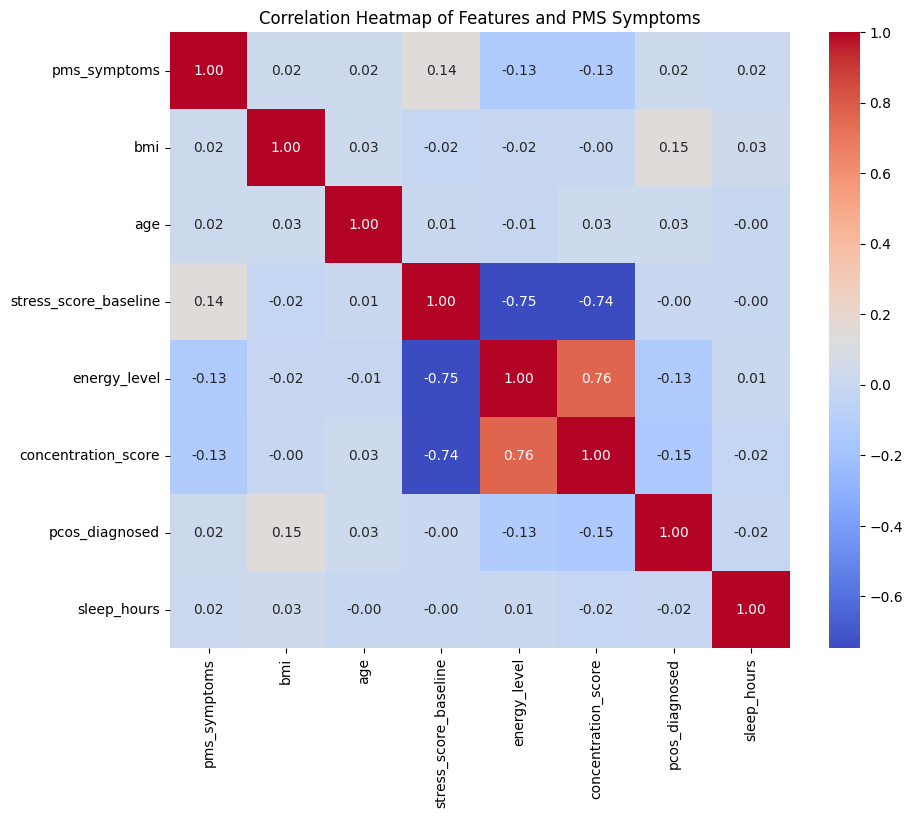

In [ ]:
correlation_matrix = user_level_df[['pms_symptoms', 'bmi', 'age', 'stress_score_baseline', 'energy_level', 'concentration_score', 'pcos_diagnosed', 'sleep_hours']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features and PMS Symptoms')
plt.show()

## Box plot of stress score by PMS status

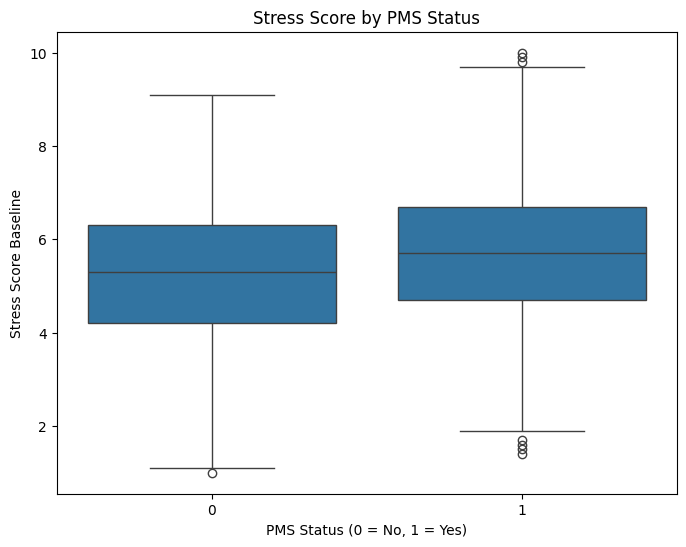

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='pms_symptoms', y='stress_score_baseline', data=user_level_df)
plt.title('Stress Score by PMS Status')
plt.xlabel('PMS Status (0 = No, 1 = Yes)')
plt.ylabel('Stress Score Baseline')
plt.show()

## Box plot of sleep hours by PMS status

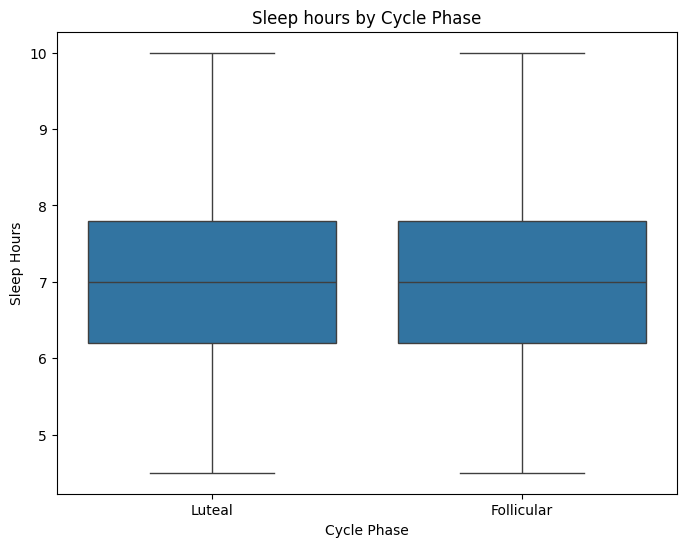

In [ ]:
# Combine the two user-level dataframes for comparison
combined_user_level_phases_df = pd.concat([user_level_df, user_level_df_follicular])

plt.figure(figsize=(8, 6))
sns.boxplot(x='cycle_phase', y='sleep_hours', data=combined_user_level_phases_df)
plt.title('Sleep hours by Cycle Phase') # Corrected typo 'Ohase' to 'Phase'
plt.xlabel('Cycle Phase')
plt.ylabel('Sleep Hours')
plt.show()

## Box plot of energy level by PMS status

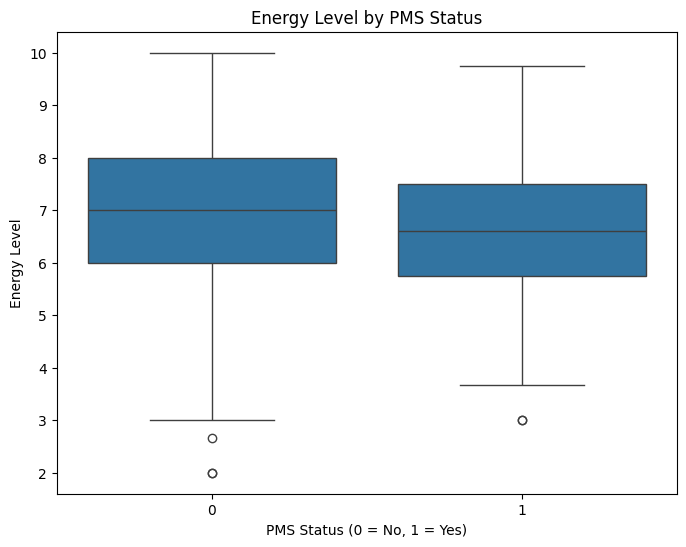

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='pms_symptoms', y='energy_level', data=user_level_df)
plt.title('Energy Level by PMS Status')
plt.xlabel('PMS Status (0 = No, 1 = Yes)')
plt.ylabel('Energy Level')
plt.show()

# Train-test split

In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split

# Define predictors (X) and target (y)
X = user_level_df[['pcos_diagnosed', 'stress_score_baseline', 'energy_level', 'concentration_score', 'sleep_hours']]
y = user_level_df['pms_symptoms']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1577, 5)
X_test shape: (395, 5)
y_train shape: (1577,)
y_test shape: (395,)


#Apply ADASYN

## ADASYN with Logistic Regression Model

In [ ]:
from imblearn.over_sampling import ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ADASYN
adasyn = ADASYN(random_state=42)

X_train_resampled, y_train_resampled = adasyn.fit_resample(
    X_train,
    y_train
)

# Model
reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    reg_model,
    X_train_resampled,
    y_train_resampled,
    cv=skf,
    scoring='f1_macro'
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean CV F1 Score:", cv_scores.mean())


# Final model training
reg_model.fit(X_train_resampled, y_train_resampled)

# Predictions
y_pred = reg_model.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = reg_model.predict(X_test)

y_probs = reg_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_probs)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc)


Cross-Validation F1 Scores: [0.51550672 0.56736657 0.54310967 0.54261466 0.59030877]
Mean CV F1 Score: 0.5517812762686897
Accuracy: 0.569620253164557
Confusion Matrix:
 [[ 52  57]
 [113 173]]
Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.48      0.38       109
           1       0.75      0.60      0.67       286

    accuracy                           0.57       395
   macro avg       0.53      0.54      0.53       395
weighted avg       0.63      0.57      0.59       395

Precision: 0.7521739130434782
Recall: 0.6048951048951049
F1 Score: 0.6705426356589147
ROC-AUC: 0.5595367934817476


## ADASYN with Random Forest Model

In [ ]:
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier

adasyn = ADASYN(random_state=42)

X_train_resampled, y_train_resampled = adasyn.fit_resample(
    X_train, # Use X_train from the split in _cwbVrLWy4FB
    y_train  # Use y_train from the split in _cwbVrLWy4FB
)

# Instantiate the model before fitting
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train_resampled,
    y_train_resampled,
    cv=skf,
    scoring='f1_macro'
)

print("RF Cross-Validation F1 Scores:", rf_cv_scores)
print("RF Mean CV F1 Score:", rf_cv_scores.mean())

rf_model.fit(X_train_resampled, y_train_resampled)

print("Model fitted with ADASYN resampled data.")

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = rf_model.predict(X_test)

y_probs = rf_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_probs)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc)


RF Cross-Validation F1 Scores: [0.72301556 0.74231145 0.70021021 0.74459703 0.719797  ]
RF Mean CV F1 Score: 0.7259862503310707
Model fitted with ADASYN resampled data.
Accuracy: 0.6481012658227848
Confusion Matrix:
 [[ 27  82]
 [ 57 229]]
Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.25      0.28       109
           1       0.74      0.80      0.77       286

    accuracy                           0.65       395
   macro avg       0.53      0.52      0.52       395
weighted avg       0.62      0.65      0.63       395

Precision: 0.7363344051446945
Recall: 0.8006993006993007
F1 Score: 0.7671691792294807
ROC-AUC: 0.5327837300314364


/tmp/ipykernel_25331/3531626683.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


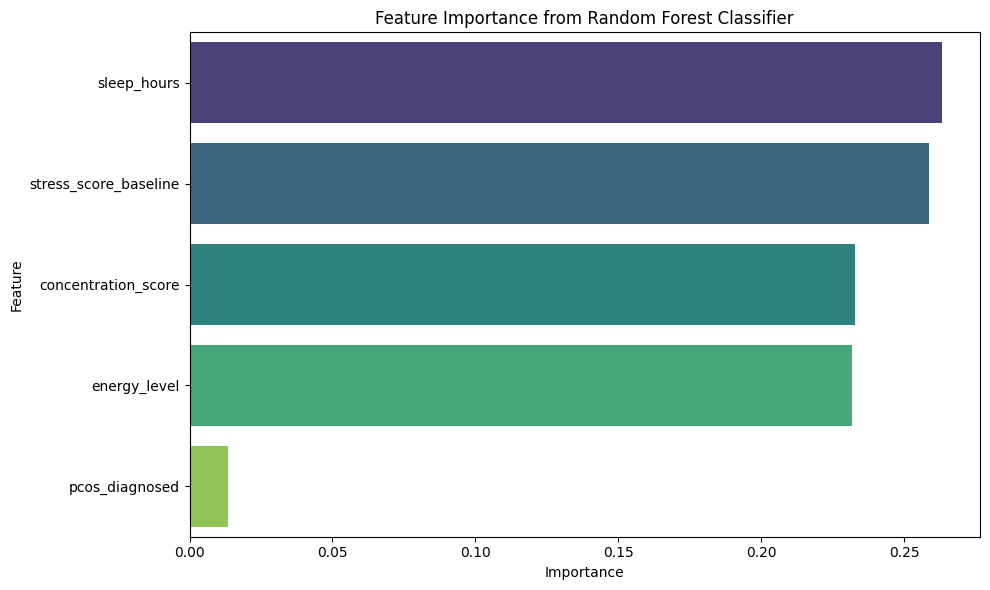

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

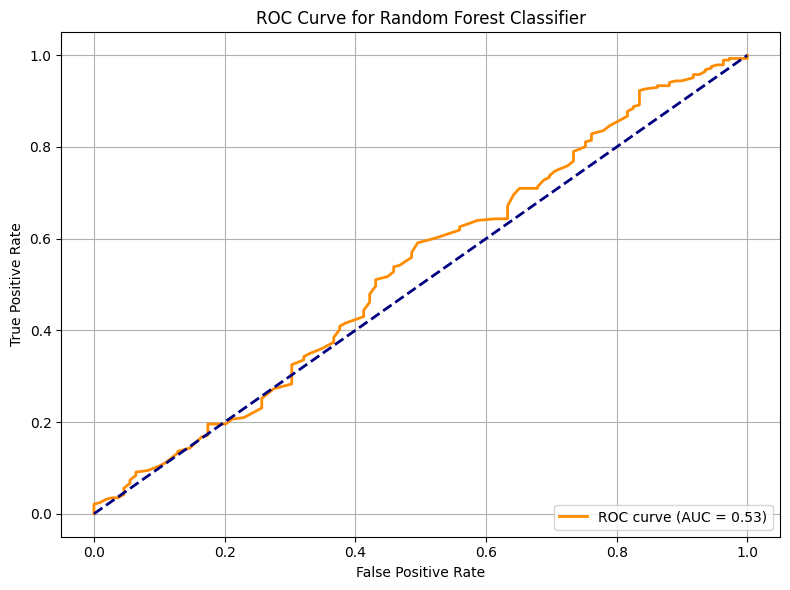

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Classifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Apply SMOTE

## SMOTE with Logistic Regression


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

# Model
smote_reg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    smote_reg_model,
    X_train_smote,
    y_train_smote,
    cv=skf,
    scoring='f1_macro'
)

print("SMOTE Logistic Regression CV F1 Scores:", cv_scores)
print("SMOTE Logistic Regression Mean CV F1 Score:", cv_scores.mean())

# Final model training
smote_reg_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred = smote_reg_model.predict(X_test)
y_probs = smote_reg_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probs)

print("SMOTE Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("SMOTE Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("SMOTE Logistic Regression Classification Report:\n", classification_report(y_test, y_pred))
print("SMOTE Logistic Regression Precision:", precision_score(y_test, y_pred))
print("SMOTE Logistic Regression Recall:", recall_score(y_test, y_pred))
print("SMOTE Logistic Regression F1 Score:", f1_score(y_test, y_pred))
print("SMOTE Logistic Regression ROC-AUC:", roc_auc)

Before SMOTE: pms_symptoms
1    1141
0     436
Name: count, dtype: int64
After SMOTE: pms_symptoms
0    1141
1    1141
Name: count, dtype: int64
SMOTE Logistic Regression CV F1 Scores: [0.57212409 0.52258961 0.58112222 0.61396825 0.54028489]
SMOTE Logistic Regression Mean CV F1 Score: 0.5660178117526645
SMOTE Logistic Regression Accuracy: 0.5594936708860759
SMOTE Logistic Regression Confusion Matrix:
 [[ 55  54]
 [120 166]]
SMOTE Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.50      0.39       109
           1       0.75      0.58      0.66       286

    accuracy                           0.56       395
   macro avg       0.53      0.54      0.52       395
weighted avg       0.63      0.56      0.58       395

SMOTE Logistic Regression Precision: 0.7545454545454545
SMOTE Logistic Regression Recall: 0.5804195804195804
SMOTE Logistic Regression F1 Score: 0.6561264822134387
SMOTE Logistic Regression ROC-A

## SMOTE with Random Forest

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Model
smote_rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv_scores = cross_val_score(
    smote_rf_model,
    X_train_smote,
    y_train_smote,
    cv=skf,
    scoring='f1_macro'
)

print("SMOTE Random Forest CV F1 Scores:", rf_cv_scores)
print("SMOTE Random Forest Mean CV F1 Score:", rf_cv_scores.mean())

# Final model training
smote_rf_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred = smote_rf_model.predict(X_test)
y_probs = smote_rf_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probs)

print("SMOTE Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("SMOTE Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("SMOTE Random Forest Classification Report:\n", classification_report(y_test, y_pred))
print("SMOTE Random Forest Precision:", precision_score(y_test, y_pred))
print("SMOTE Random Forest Recall:", recall_score(y_test, y_pred))
print("SMOTE Random Forest F1 Score:", f1_score(y_test, y_pred))
print("SMOTE Random Forest ROC-AUC:", roc_auc)

SMOTE Random Forest CV F1 Scores: [0.76146969 0.74833958 0.73903383 0.73665974 0.75156094]
SMOTE Random Forest Mean CV F1 Score: 0.7474127566705109
SMOTE Random Forest Accuracy: 0.6531645569620254
SMOTE Random Forest Confusion Matrix:
 [[ 30  79]
 [ 58 228]]
SMOTE Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.34      0.28      0.30       109
           1       0.74      0.80      0.77       286

    accuracy                           0.65       395
   macro avg       0.54      0.54      0.54       395
weighted avg       0.63      0.65      0.64       395

SMOTE Random Forest Precision: 0.742671009771987
SMOTE Random Forest Recall: 0.7972027972027972
SMOTE Random Forest F1 Score: 0.7689713322091062
SMOTE Random Forest ROC-AUC: 0.567139282735613
